In [32]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [33]:
# initializing the circuit
qc = QuantumCircuit(2,2) # 2 qubits for the math, 2 classical bits for the answers

In [34]:
# applying gates to create a perfect bell states
qc.h(0)  # put qubit 0 into a 50/50 superposition
qc.cx(0,1)  # CNOT gate mathematically locks qubit 1 to qubit 0

In [35]:
# measuring the qubits
qc.measure([0,1],[0,1])  # [list of qubits] , [list of classical bits]

In [36]:
# booting up the virtual quantum computer
simulator = AerSimulator()
compiled_circuit = transpile(qc,simulator)

In [37]:
# running the circuit for 1024 times to get reliable statistical data
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

Perfect quantum key result:  {'11': 503, '00': 521}


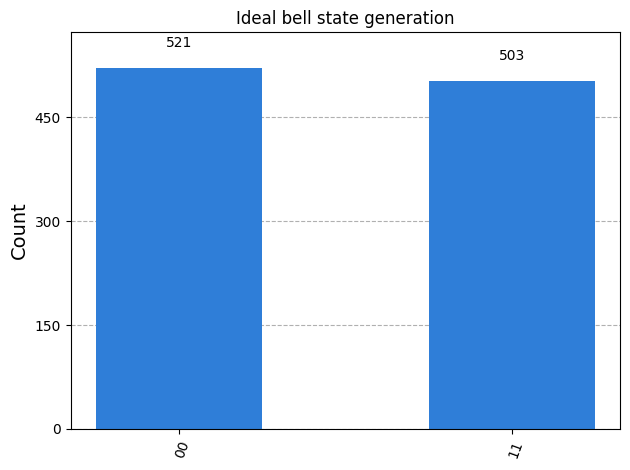

In [38]:
# output the raw data and plotting the graph
print("Perfect quantum key result: ",counts)
fig = plot_histogram(counts, title="Ideal bell state generation", color='#2f7ed8')